In [1]:
import os

# Xem tất cả file trong dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__results__.html
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__notebook__.ipynb
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/android_ransomware_preprocessed.csv
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__output__.json
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/custom.css
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__results___files/__results___25_0.png
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__results___files/__results___19_0.png
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__results___files/__results___31_0.png
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__results___files/__results___22_0.png
/kaggle/input/notebooks/ranausmancs/android-ransomware-detection/__results___files/__results___45_0.png
/kaggle/input/notebooks/ranausmancs/android-ransomware-d

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/loreal113/android-ransomeware-csv/Android_Ransomeware.csv')

print("Shape:", df.shape)
print("\n5 dòng đầu:")
print(df.head())
print("\nPhân phối nhãn:")
print(df['Label'].value_counts())

Shape: (392034, 86)

5 dòng đầu:
   Unnamed: 0                                 Flow ID    Source IP  \
0           0   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211   
1           1   172.217.2.174-10.42.0.211-443-51023-6  10.42.0.211   
2           2  172.217.12.174-10.42.0.211-443-34259-6  10.42.0.211   
3           3   172.217.10.74-10.42.0.211-443-55509-6  10.42.0.211   
4           4   172.217.2.174-10.42.0.211-443-44852-6  10.42.0.211   

    Source Port  Destination IP   Destination Port   Protocol  \
0         51023   172.217.2.174                443          6   
1         51023   172.217.2.174                443          6   
2         34259  172.217.12.174                443          6   
3         55509   172.217.10.74                443          6   
4         44852   172.217.2.174                443          6   

             Timestamp   Flow Duration   Total Fwd Packets  ...  \
0  16/06/2017 03:55:47          151054                   6  ...   
1  16/06/2017 03:55:4

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# 1. Xóa khoảng trắng ở đầu tên cột
df.columns = df.columns.str.strip()
print("Đã xử lý tên cột xong!")

# 2. Bỏ các cột không cần thiết
df = df.drop(columns=['Unnamed: 0', 'Flow ID', 'Source IP', 
                       'Destination IP', 'Timestamp'])

# 3. Xử lý giá trị vô cực và NaN
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(f"Sau khi xử lý NaN: {df.shape}")

# 4. Mã hóa nhãn: Benign=0, Ransomware=1
df['Label_binary'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)
print("\nPhân phối nhãn binary:")
print(df['Label_binary'].value_counts())

# 5. Tách features và nhãn
X = df.drop(columns=['Label', 'Label_binary'])
y = df['Label_binary']

# 6. Under-sampling cân bằng dữ liệu
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)
print(f"\nSau under-sampling: {X_resampled.shape}")
print(y_resampled.value_counts())

# 7. Chia train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# 8. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")
print("\n✅ Tiền xử lý hoàn tất!")

Đã xử lý tên cột xong!
Sau khi xử lý NaN: (392034, 81)

Phân phối nhãn binary:
Label_binary
1    348943
0     43091
Name: count, dtype: int64

Sau under-sampling: (86182, 80)
Label_binary
0    43091
1    43091
Name: count, dtype: int64

Train set: (68945, 80)
Test set:  (17237, 80)

✅ Tiền xử lý hoàn tất!


In [4]:
#Huấn luyện các mô hình M
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

results = {}

def evaluate_model(name, y_true, y_pred):
    results[name] = {
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted') * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted') * 100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted') * 100, 2)
    }
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {results[name]['Accuracy']}%")
    print(f"Precision: {results[name]['Precision']}%")
    print(f"Recall:    {results[name]['Recall']}%")
    print(f"F1-Score:  {results[name]['F1-Score']}%")

# 1. Decision Tree
print("⏳ Đang huấn luyện Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
evaluate_model('Decision Tree', y_test, dt.predict(X_test_scaled))

# 2. KNN
print("\n⏳ Đang huấn luyện KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
evaluate_model('KNN', y_test, knn.predict(X_test_scaled))

# 3. SVM (dùng LinearSVC cho nhanh hơn vì dataset lớn)
print("\n⏳ Đang huấn luyện SVM...")
from sklearn.svm import LinearSVC
svm = LinearSVC(random_state=42, max_iter=2000)
svm.fit(X_train_scaled, y_train)
evaluate_model('SVM', y_test, svm.predict(X_test_scaled))

print("\n✅ Huấn luyện 3 mô hình xong!")

⏳ Đang huấn luyện Decision Tree...

=== Decision Tree ===
Accuracy:  74.38%
Precision: 74.39%
Recall:    74.38%
F1-Score:  74.38%

⏳ Đang huấn luyện KNN...

=== KNN ===
Accuracy:  64.92%
Precision: 64.97%
Recall:    64.92%
F1-Score:  64.9%

⏳ Đang huấn luyện SVM...

=== SVM ===
Accuracy:  54.71%
Precision: 54.72%
Recall:    54.71%
F1-Score:  54.71%

✅ Huấn luyện 3 mô hình xong!


In [5]:
# 4. Ensemble (DT + KNN + SVM)
print("⏳ Đang huấn luyện Ensemble...")
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Wrap LinearSVC để dùng được trong VotingClassifier
svm_cal = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000))
ensemble = VotingClassifier(
    estimators=[('dt', dt), ('knn', knn), ('svm', svm_cal)],
    voting='soft'
)
ensemble.fit(X_train_scaled, y_train)
evaluate_model('Ensemble', y_test, ensemble.predict(X_test_scaled))
print("✅ Ensemble xong!")

⏳ Đang huấn luyện Ensemble...

=== Ensemble ===
Accuracy:  74.21%
Precision: 74.23%
Recall:    74.21%
F1-Score:  74.21%
✅ Ensemble xong!


In [6]:
# 5. FNN - Feedforward Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("⏳ Đang huấn luyện FNN...")

model_fnn = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_fnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_fnn.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Đánh giá FNN
y_pred_fnn = (model_fnn.predict(X_test_scaled) > 0.5).astype(int)
evaluate_model('FNN', y_test, y_pred_fnn)
print("✅ FNN xong!")

2026-04-26 07:55:16.960559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777190117.171449      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777190117.232446      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777190117.762531      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777190117.762569      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777190117.762572      55 computation_placer.cc:177] computation placer alr

⏳ Đang huấn luyện FNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-26 07:55:43.615459: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5220 - loss: 0.7506 - val_accuracy: 0.5524 - val_loss: 0.6810
Epoch 2/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5401 - loss: 0.6898 - val_accuracy: 0.5554 - val_loss: 0.6812
Epoch 3/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5498 - loss: 0.6841 - val_accuracy: 0.5599 - val_loss: 0.6777
Epoch 4/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5633 - loss: 0.6784 - val_accuracy: 0.5683 - val_loss: 0.6770
Epoch 5/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5630 - loss: 0.6779 - val_accuracy: 0.5696 - val_loss: 0.6744
Epoch 6/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5612 - loss: 0.6761 - val_accuracy: 0.5736 - val_loss: 0.6741
Epoch 7/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5691 - loss: 0.6725 - val_accuracy: 0.5788 - val_loss: 0.6719
Epoch 8/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5696 - loss: 0.6719 - val_accuracy: 0.

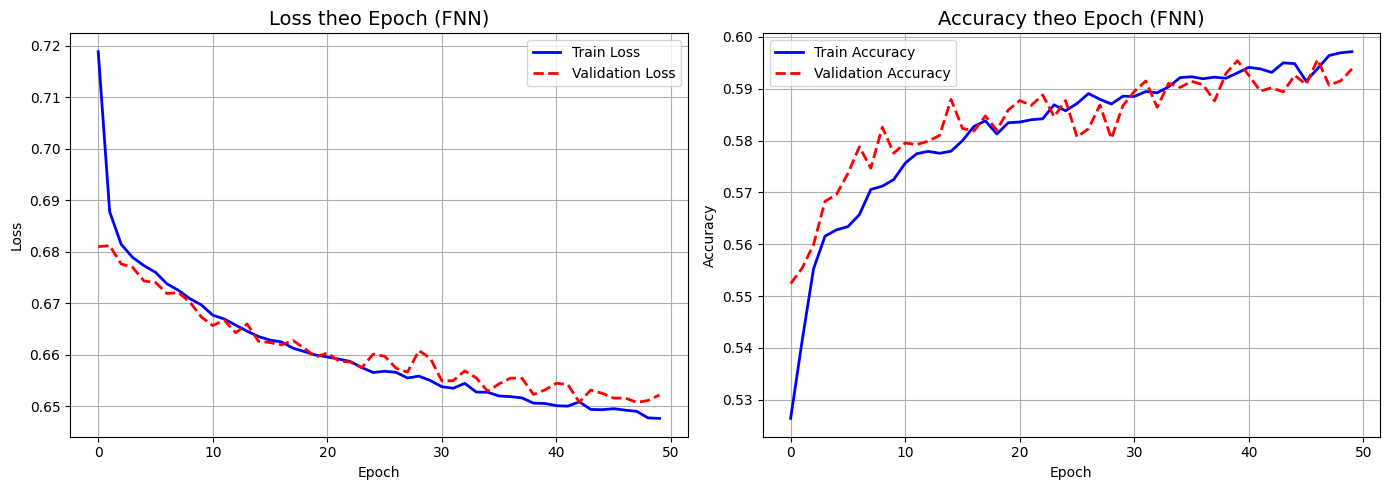

✅ Đã lưu biểu đồ loss/accuracy!


In [7]:
# 6. VẼ BIỂU ĐỒ LOSS VÀ ACCURACY THEO EPOCH 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2, linestyle='--')
ax1.set_title('Loss theo Epoch (FNN)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
ax2.set_title('Accuracy theo Epoch (FNN)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('bieu_do_loss_accuracy.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ loss/accuracy!")


===== BẢNG SO SÁNH KẾT QUẢ =====
               Accuracy  Precision  Recall  F1-Score
Decision Tree     74.38      74.39   74.38     74.38
KNN               64.92      64.97   64.92     64.90
SVM               54.71      54.72   54.71     54.71
Ensemble          74.21      74.23   74.21     74.21
FNN               60.05      61.16   60.05     59.08


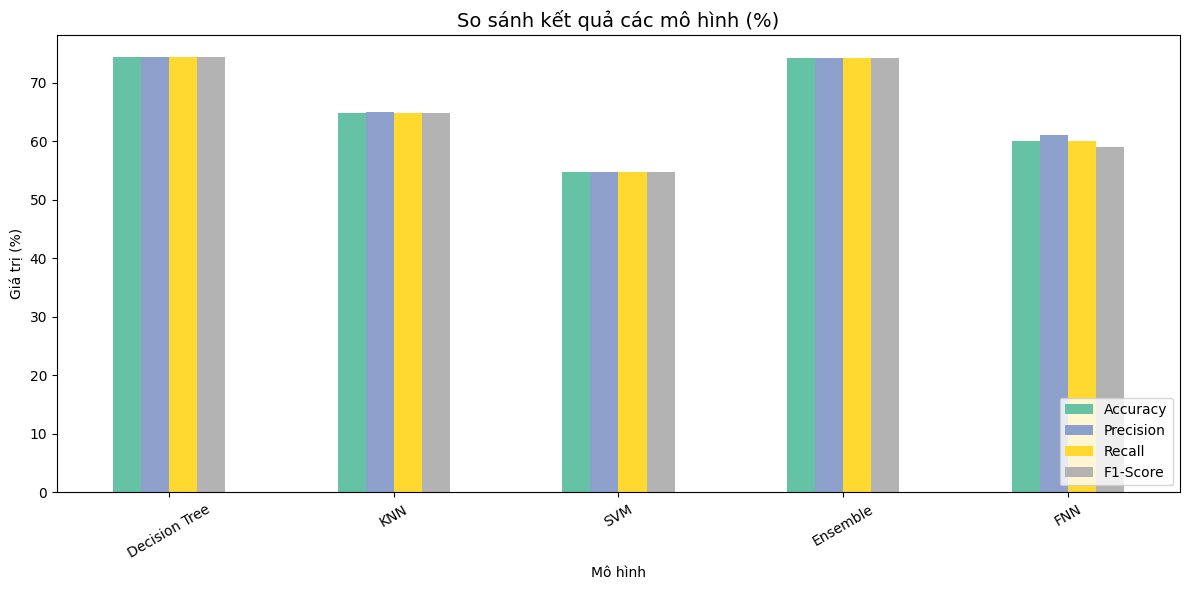

✅ Đã lưu bảng kết quả!


In [8]:
#Bảng so sánh tất cả mô hình
import pandas as pd

df_results = pd.DataFrame(results).T
print("\n===== BẢNG SO SÁNH KẾT QUẢ =====")
print(df_results.to_string())

# Vẽ biểu đồ so sánh
df_results.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('So sánh kết quả các mô hình (%)', fontsize=14)
plt.xlabel('Mô hình')
plt.ylabel('Giá trị (%)')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('bang_ket_qua.png', dpi=300)
plt.show()
print("✅ Đã lưu bảng kết quả!")

Mô hình tốt nhất: Decision Tree (74.38%)


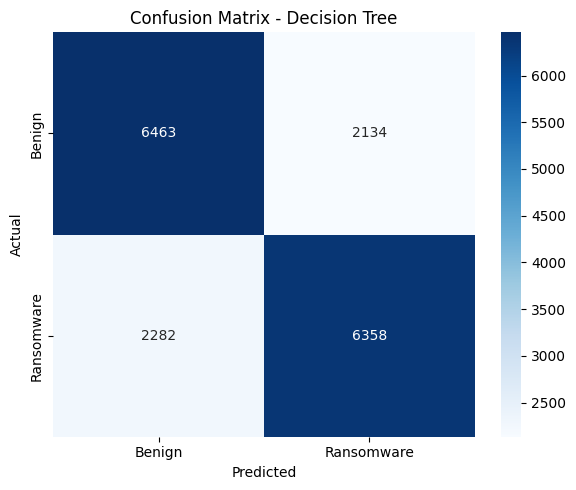

✅ Đã lưu Confusion Matrix!


In [9]:
#Confusion Matrix mô hình tốt nhất
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Tìm mô hình có accuracy cao nhất
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
print(f"Mô hình tốt nhất: {best_model_name} ({results[best_model_name]['Accuracy']}%)")

# Vẽ confusion matrix của DT
cm = confusion_matrix(y_test, dt.predict(X_test_scaled))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Ransomware'],
            yticklabels=['Benign', 'Ransomware'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("✅ Đã lưu Confusion Matrix!")

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

# Chọn 19 features tốt nhất
selector = SelectKBest(f_classif, k=19)
X_train_19 = selector.fit_transform(X_train_scaled, y_train)
X_test_19 = selector.transform(X_test_scaled)

# In ra tên 19 features được chọn
feature_names = X.columns[selector.get_support()]
print("19 Features được chọn:")
for i, f in enumerate(feature_names, 1):
    print(f"  {i}. {f}")

# Chạy lại Decision Tree với 19 features
dt_19 = DecisionTreeClassifier(random_state=42)
dt_19.fit(X_train_19, y_train)
evaluate_model('DT (19 features)', y_test, dt_19.predict(X_test_19))

# So sánh Experiment 1 vs Experiment 2
print("\n===== SO SÁNH 2 THÍ NGHIỆM =====")
print(f"Experiment 1 - DT (All features): {results['Decision Tree']['Accuracy']}%")
print(f"Experiment 2 - DT (19 features):  {results['DT (19 features)']['Accuracy']}%")

19 Features được chọn:
  1. Protocol
  2. Fwd Packet Length Max
  3. Fwd Packet Length Min
  4. Fwd Packet Length Mean
  5. Fwd Packet Length Std
  6. Bwd Packet Length Min
  7. Flow Bytes/s
  8. Flow Packets/s
  9. Flow IAT Mean
  10. Flow IAT Min
  11. Bwd IAT Std
  12. Fwd Packets/s
  13. Bwd Packets/s
  14. Min Packet Length
  15. Max Packet Length
  16. ACK Flag Count
  17. URG Flag Count
  18. Avg Fwd Segment Size
  19. Init_Win_bytes_forward


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [33 34 35 47 51 52 58 59 60 61 62 63] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



=== DT (19 features) ===
Accuracy:  68.59%
Precision: 68.59%
Recall:    68.59%
F1-Score:  68.58%

===== SO SÁNH 2 THÍ NGHIỆM =====
Experiment 1 - DT (All features): 74.38%
Experiment 2 - DT (19 features):  68.59%


In [11]:
import joblib

# Lưu models
joblib.dump(dt, 'model_decision_tree.pkl')
joblib.dump(knn, 'model_knn.pkl')
joblib.dump(scaler, 'scaler.pkl')
model_fnn.save('model_fnn.h5')

print("✅ Đã lưu tất cả models!")
print("\nCác file cần tải về để nộp bài:")
print("  1. bieu_do_loss_accuracy.png")
print("  2. bang_ket_qua.png")
print("  3. confusion_matrix.png")
print("  4. model_decision_tree.pkl")
print("  5. model_fnn.h5")
print("  6. File notebook .ipynb")

✅ Đã lưu tất cả models!

Các file cần tải về để nộp bài:
  1. bieu_do_loss_accuracy.png
  2. bang_ket_qua.png
  3. confusion_matrix.png
  4. model_decision_tree.pkl
  5. model_fnn.h5
  6. File notebook .ipynb


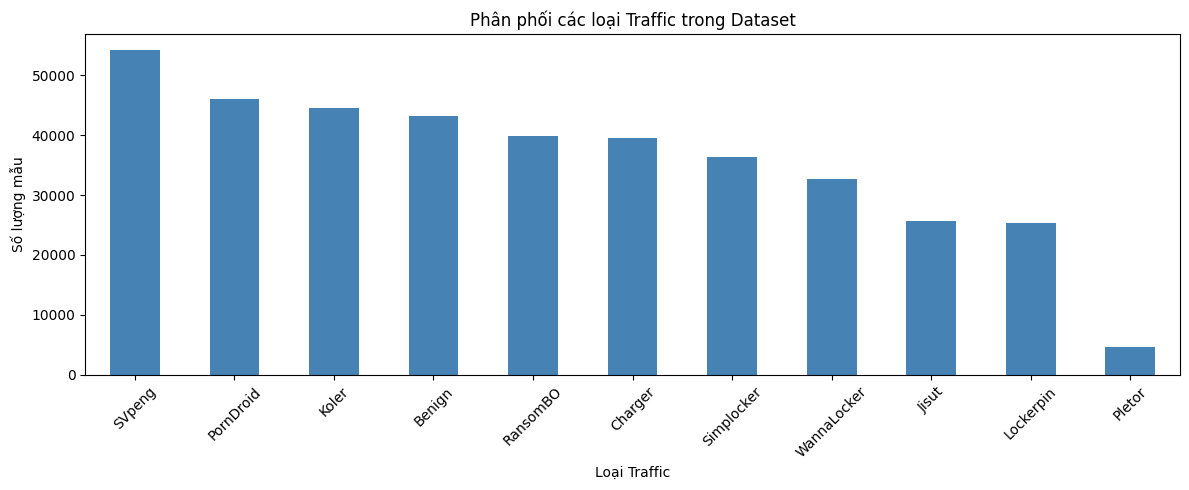

✅ Đã lưu biểu đồ phân phối nhãn!


In [12]:
# Biểu đồ phân phối nhãn dataset
plt.figure(figsize=(12, 5))
df['Label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Phân phối các loại Traffic trong Dataset')
plt.xlabel('Loại Traffic')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('phan_phoi_nhan.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ phân phối nhãn!")

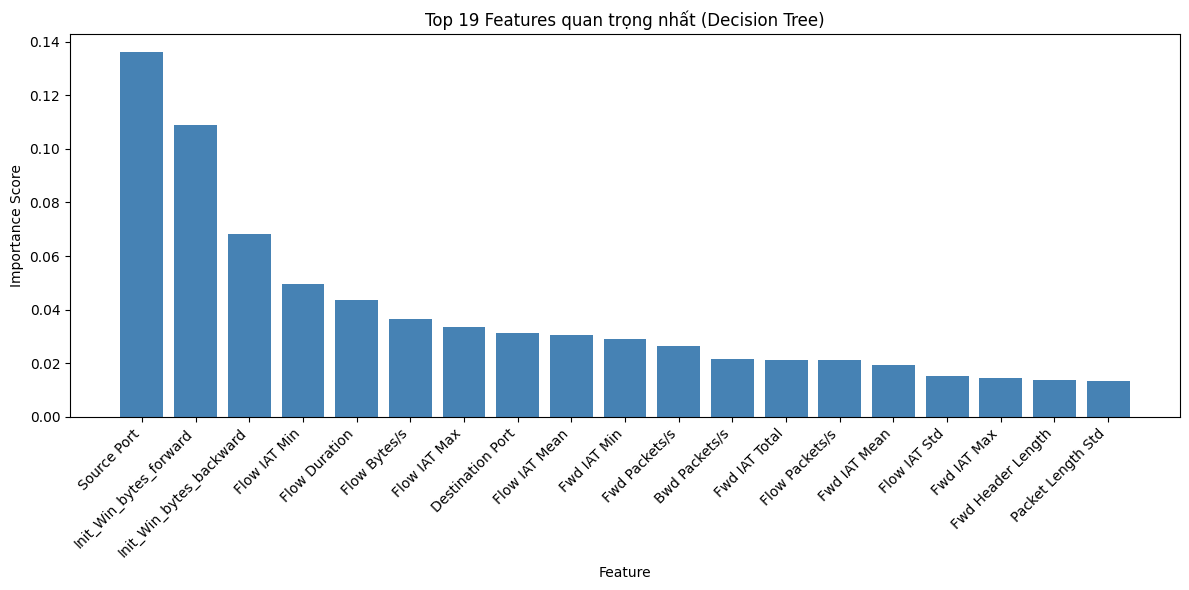

✅ Đã lưu biểu đồ Feature Importance!


In [13]:
#Biểu đồ Feature Importance
importances = dt.feature_importances_
feature_names_all = X.columns
indices = importances.argsort()[::-1][:19]

plt.figure(figsize=(12, 6))
plt.bar(range(19), importances[indices], color='steelblue')
plt.xticks(range(19), [feature_names_all[i] for i in indices], rotation=45, ha='right')
plt.title('Top 19 Features quan trọng nhất (Decision Tree)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ Feature Importance!")

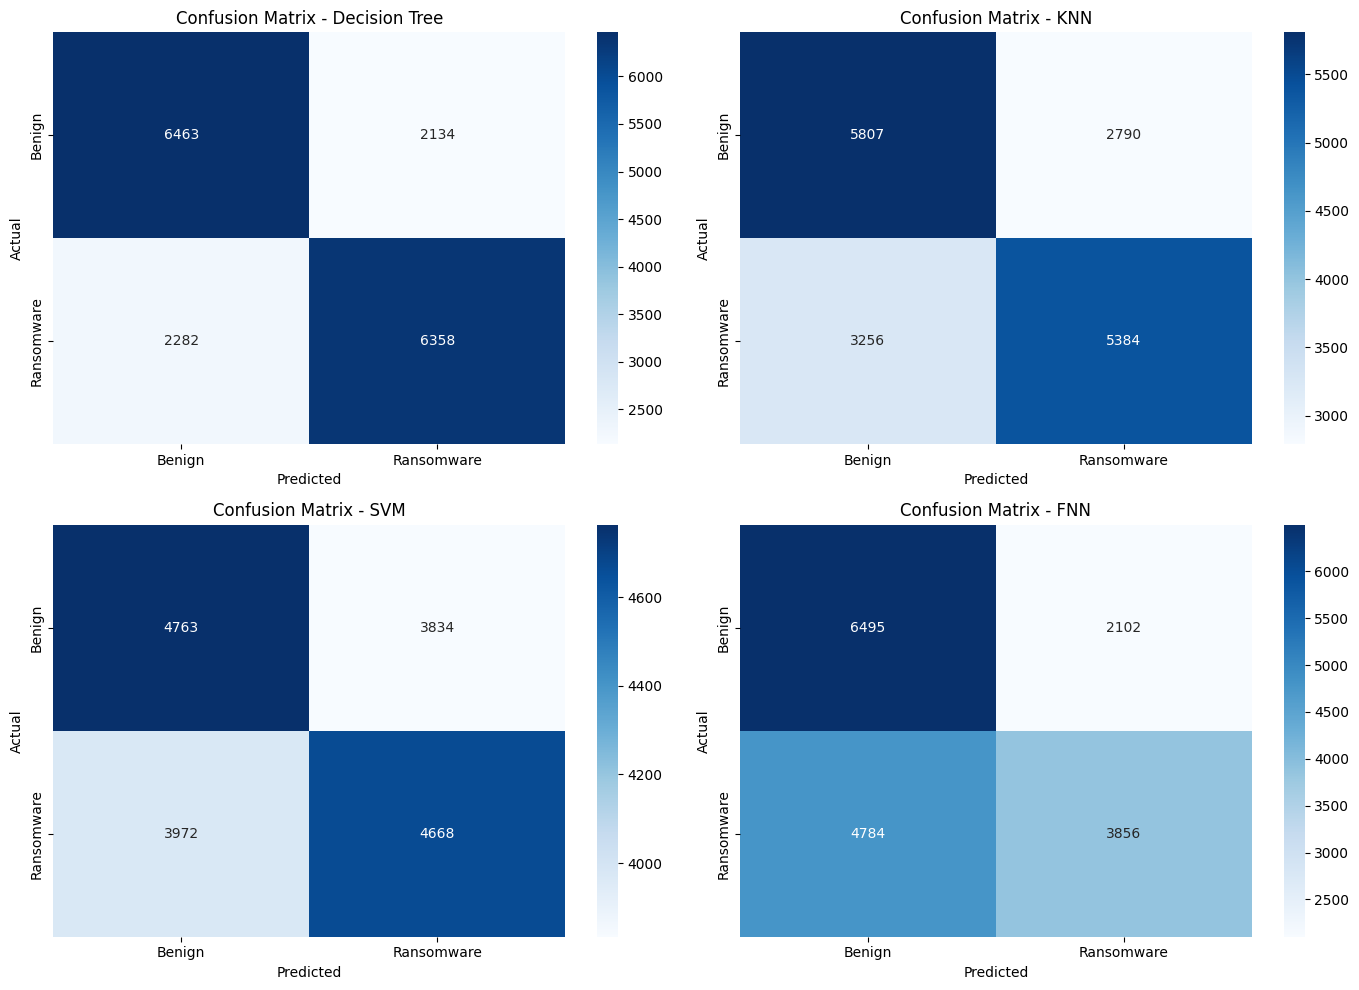

✅ Đã lưu Confusion Matrix tất cả mô hình!


In [14]:
# Confusion Matrix cho tất cả mô hình 
models_pred = {
    'Decision Tree': dt.predict(X_test_scaled),
    'KNN': knn.predict(X_test_scaled),
    'SVM': svm.predict(X_test_scaled),
    'FNN': y_pred_fnn.flatten()
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(models_pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Ransomware'],
                yticklabels=['Benign', 'Ransomware'])
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_all.png', dpi=300)
plt.show()
print("✅ Đã lưu Confusion Matrix tất cả mô hình!")


=== KNN (19 features) ===
Accuracy:  67.38%
Precision: 67.43%
Recall:    67.38%
F1-Score:  67.37%

=== SVM (19 features) ===
Accuracy:  52.0%
Precision: 52.0%
Recall:    52.0%
F1-Score:  51.9%

========== EXPERIMENT 1 — All features ==========
               Accuracy  Precision  Recall  F1-Score
Decision Tree     74.38      74.39   74.38     74.38
KNN               64.92      64.97   64.92     64.90
SVM               54.71      54.72   54.71     54.71
Ensemble          74.21      74.23   74.21     74.21
FNN               60.05      61.16   60.05     59.08

========== EXPERIMENT 2 — 19 features ==========
                   Accuracy  Precision  Recall  F1-Score
DT (19 features)      68.59      68.59   68.59     68.58
KNN (19 features)     67.38      67.43   67.38     67.37
SVM (19 features)     52.00      52.00   52.00     51.90


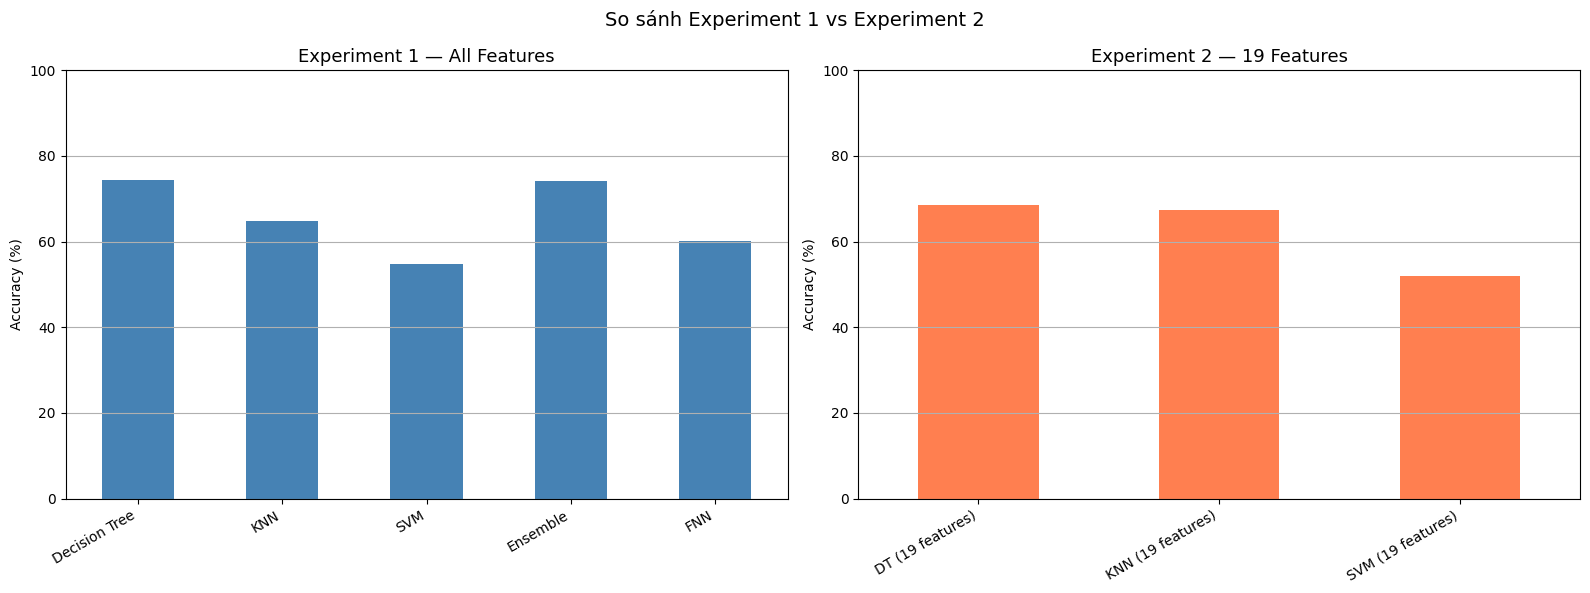

✅ Đã lưu biểu đồ so sánh 2 experiments!


In [15]:
# Chạy KNN với 19 features
knn_19 = KNeighborsClassifier(n_neighbors=5)
knn_19.fit(X_train_19, y_train)
evaluate_model('KNN (19 features)', y_test, knn_19.predict(X_test_19))

# Chạy SVM với 19 features
svm_19 = LinearSVC(random_state=42, max_iter=2000)
svm_19.fit(X_train_19, y_train)
evaluate_model('SVM (19 features)', y_test, svm_19.predict(X_test_19))

# In bảng so sánh đầy đủ
print("\n========== EXPERIMENT 1 — All features ==========")
exp1_keys = ['Decision Tree', 'KNN', 'SVM', 'Ensemble', 'FNN']
df_exp1 = pd.DataFrame({k: results[k] for k in exp1_keys if k in results}).T
print(df_exp1.to_string())

print("\n========== EXPERIMENT 2 — 19 features ==========")
exp2_keys = ['DT (19 features)', 'KNN (19 features)', 'SVM (19 features)']
df_exp2 = pd.DataFrame({k: results[k] for k in exp2_keys if k in results}).T
print(df_exp2.to_string())

# Vẽ biểu đồ so sánh 2 experiments
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_exp1['Accuracy'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Experiment 1 — All Features', fontsize=13)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)
ax1.set_xticklabels(df_exp1.index, rotation=30, ha='right')
ax1.grid(axis='y')

df_exp2['Accuracy'].plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Experiment 2 — 19 Features', fontsize=13)
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.set_xticklabels(df_exp2.index, rotation=30, ha='right')
ax2.grid(axis='y')

plt.suptitle('So sánh Experiment 1 vs Experiment 2', fontsize=14)
plt.tight_layout()
plt.savefig('so_sanh_experiment.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ so sánh 2 experiments!")

In [16]:
from IPython.display import FileLink
import os

files_to_download = [
    'phan_phoi_nhan.png',
    'feature_importance.png',
    'bieu_do_loss_accuracy.png',
    'bang_ket_qua.png',
    'confusion_matrix.png',
    'confusion_matrix_all.png',
    'so_sanh_experiment.png'
]

print("Các file cần tải về:")
for f in files_to_download:
    if os.path.exists(f'/kaggle/working/{f}'):
        print(f"  ✅ {f}")
    else:
        print(f"  ❌ {f} — không tìm thấy")

Các file cần tải về:
  ✅ phan_phoi_nhan.png
  ✅ feature_importance.png
  ✅ bieu_do_loss_accuracy.png
  ✅ bang_ket_qua.png
  ✅ confusion_matrix.png
  ✅ confusion_matrix_all.png
  ✅ so_sanh_experiment.png


In [17]:
# Mô phỏng phát hiện traffic mới
import numpy as np

print("=== MÔ PHỎNG PHÁT HIỆN TẤN CÔNG RANSOMWARE ===\n")

# Lấy 5 mẫu ngẫu nhiên từ tập test
sample_indices = np.random.choice(len(X_test_scaled), 10, replace=False)
X_sample = X_test_scaled[sample_indices]
y_sample_true = y_test.iloc[sample_indices].values

# Dự đoán bằng mô hình tốt nhất (Decision Tree)
y_sample_pred = dt.predict(X_sample)

for i in range(10):
    thuc_te = "🔴 RANSOMWARE" if y_sample_true[i] == 1 else "🟢 Benign"
    du_doan = "🔴 RANSOMWARE" if y_sample_pred[i] == 1 else "🟢 Benign"
    ket_qua = "✅ Đúng" if y_sample_true[i] == y_sample_pred[i] else "❌ Sai"
    print(f"Mẫu {i+1}: Thực tế={thuc_te} | Dự đoán={du_doan} | {ket_qua}")

=== MÔ PHỎNG PHÁT HIỆN TẤN CÔNG RANSOMWARE ===

Mẫu 1: Thực tế=🔴 RANSOMWARE | Dự đoán=🟢 Benign | ❌ Sai
Mẫu 2: Thực tế=🔴 RANSOMWARE | Dự đoán=🔴 RANSOMWARE | ✅ Đúng
Mẫu 3: Thực tế=🔴 RANSOMWARE | Dự đoán=🟢 Benign | ❌ Sai
Mẫu 4: Thực tế=🟢 Benign | Dự đoán=🔴 RANSOMWARE | ❌ Sai
Mẫu 5: Thực tế=🟢 Benign | Dự đoán=🟢 Benign | ✅ Đúng
Mẫu 6: Thực tế=🔴 RANSOMWARE | Dự đoán=🟢 Benign | ❌ Sai
Mẫu 7: Thực tế=🔴 RANSOMWARE | Dự đoán=🔴 RANSOMWARE | ✅ Đúng
Mẫu 8: Thực tế=🔴 RANSOMWARE | Dự đoán=🔴 RANSOMWARE | ✅ Đúng
Mẫu 9: Thực tế=🟢 Benign | Dự đoán=🟢 Benign | ✅ Đúng
Mẫu 10: Thực tế=🔴 RANSOMWARE | Dự đoán=🔴 RANSOMWARE | ✅ Đúng


In [18]:
import os

print("Các file trong /kaggle/working:")
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  📄 {f} ({size/1024:.1f} KB)")

Các file trong /kaggle/working:
  📄 .virtual_documents (4.0 KB)
  📄 scaler.pkl (4.2 KB)
  📄 model_decision_tree.pkl (1874.6 KB)
  📄 phan_phoi_nhan.png (161.4 KB)
  📄 bieu_do_loss_accuracy.png (267.3 KB)
  📄 feature_importance.png (282.0 KB)
  📄 model_knn.pkl (43630.1 KB)
  📄 so_sanh_experiment.png (200.0 KB)
  📄 confusion_matrix.png (98.9 KB)
  📄 model_fnn.h5 (793.4 KB)
  📄 confusion_matrix_all.png (305.0 KB)
  📄 bang_ket_qua.png (138.2 KB)


In [19]:
!pip install xgboost

In [20]:
#Mô hình cải tiến — Random Forest + XGBoost
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Random Forest
print("⏳ Đang huấn luyện Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
evaluate_model('Random Forest', y_test, rf.predict(X_test_scaled))

# 2. XGBoost
print("\n⏳ Đang huấn luyện XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
evaluate_model('XGBoost', y_test, xgb.predict(X_test_scaled))

print("\n✅ Huấn luyện mô hình cải tiến xong!")

⏳ Đang huấn luyện Random Forest...

=== Random Forest ===
Accuracy:  76.83%
Precision: 76.87%
Recall:    76.83%
F1-Score:  76.83%

⏳ Đang huấn luyện XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:59:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Accuracy:  74.97%
Precision: 75.03%
Recall:    74.97%
F1-Score:  74.96%

✅ Huấn luyện mô hình cải tiến xong!


========== MÔ HÌNH GỐC ==========
               Accuracy  Precision  Recall  F1-Score
Decision Tree     74.38      74.39   74.38     74.38
KNN               64.92      64.97   64.92     64.90
SVM               54.71      54.72   54.71     54.71
Ensemble          74.21      74.23   74.21     74.21
FNN               60.05      61.16   60.05     59.08

========== MÔ HÌNH CẢI TIẾN ==========
               Accuracy  Precision  Recall  F1-Score
Random Forest     76.83      76.87   76.83     76.83
XGBoost           74.97      75.03   74.97     74.96


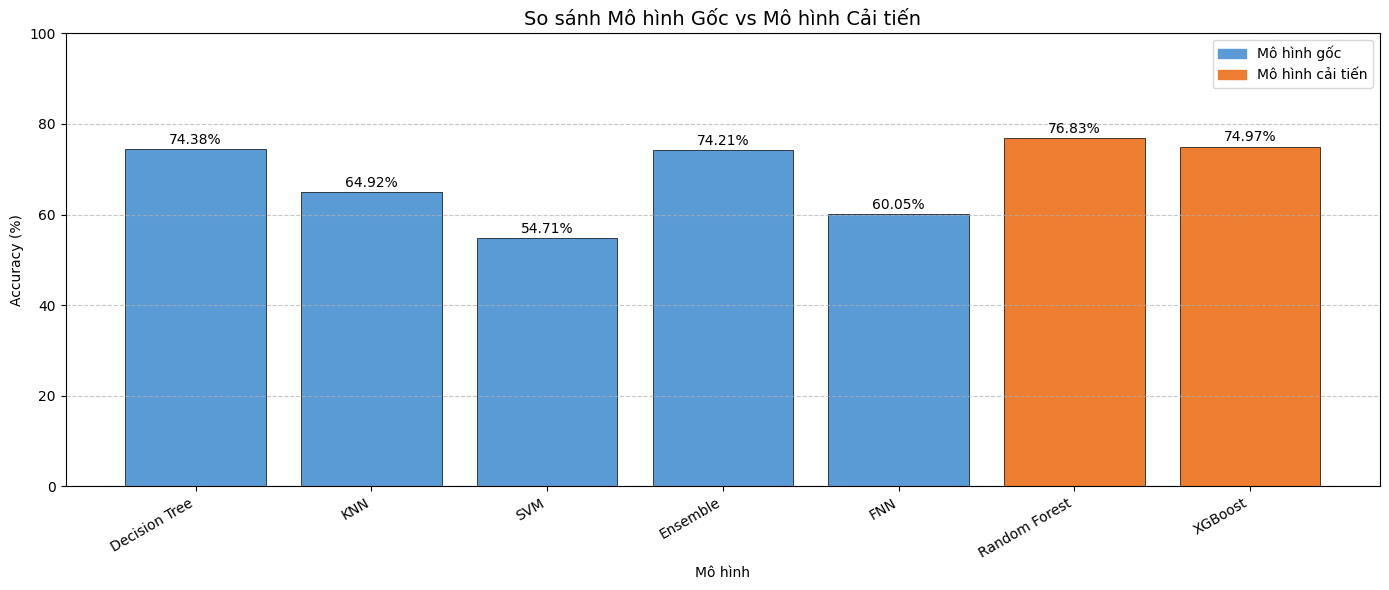

✅ Đã lưu biểu đồ so sánh!


In [21]:
# Tổng hợp kết quả gốc và cải tiến
ket_qua_goc = {
    'Decision Tree': results['Decision Tree'],
    'KNN':           results['KNN'],
    'SVM':           results['SVM'],
    'Ensemble':      results['Ensemble'],
    'FNN':           results['FNN']
}

ket_qua_cai_tien = {
    'Random Forest': results['Random Forest'],
    'XGBoost':       results['XGBoost']
}

print("========== MÔ HÌNH GỐC ==========")
df_goc = pd.DataFrame(ket_qua_goc).T
print(df_goc.to_string())

print("\n========== MÔ HÌNH CẢI TIẾN ==========")
df_cai_tien = pd.DataFrame(ket_qua_cai_tien).T
print(df_cai_tien.to_string())

# Vẽ biểu đồ so sánh gốc vs cải tiến
all_results = {**ket_qua_goc, **ket_qua_cai_tien}
df_all = pd.DataFrame(all_results).T

colors = ['#5b9bd5'] * 5 + ['#ed7d31'] * 2  # xanh = gốc, cam = cải tiến

plt.figure(figsize=(14, 6))
bars = plt.bar(df_all.index, df_all['Accuracy'], color=colors, edgecolor='black', linewidth=0.5)

# Thêm giá trị lên đầu mỗi cột
for bar, val in zip(bars, df_all['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=10)

plt.title('So sánh Mô hình Gốc vs Mô hình Cải tiến', fontsize=14)
plt.xlabel('Mô hình')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=30, ha='right')

# Chú thích màu
from matplotlib.patches import Patch
legend = [Patch(color='#5b9bd5', label='Mô hình gốc'),
          Patch(color='#ed7d31', label='Mô hình cải tiến')]
plt.legend(handles=legend)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('so_sanh_goc_vs_cai_tien.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ so sánh!")

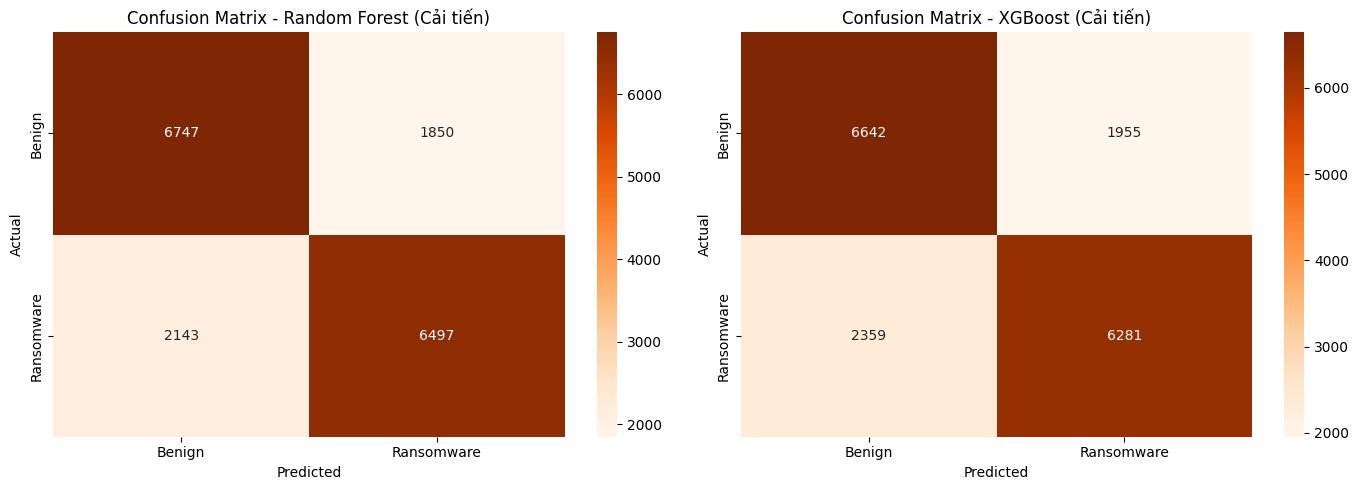

✅ Đã lưu Confusion Matrix mô hình cải tiến!


In [22]:
#Confusion Matrix mô hình cải tiến
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, rf.predict(X_test_scaled))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax1,
            xticklabels=['Benign', 'Ransomware'],
            yticklabels=['Benign', 'Ransomware'])
ax1.set_title('Confusion Matrix - Random Forest (Cải tiến)')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# XGBoost
cm_xgb = confusion_matrix(y_test, xgb.predict(X_test_scaled))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=['Benign', 'Ransomware'],
            yticklabels=['Benign', 'Ransomware'])
ax2.set_title('Confusion Matrix - XGBoost (Cải tiến)')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_cai_tien.png', dpi=300)
plt.show()
print("✅ Đã lưu Confusion Matrix mô hình cải tiến!")

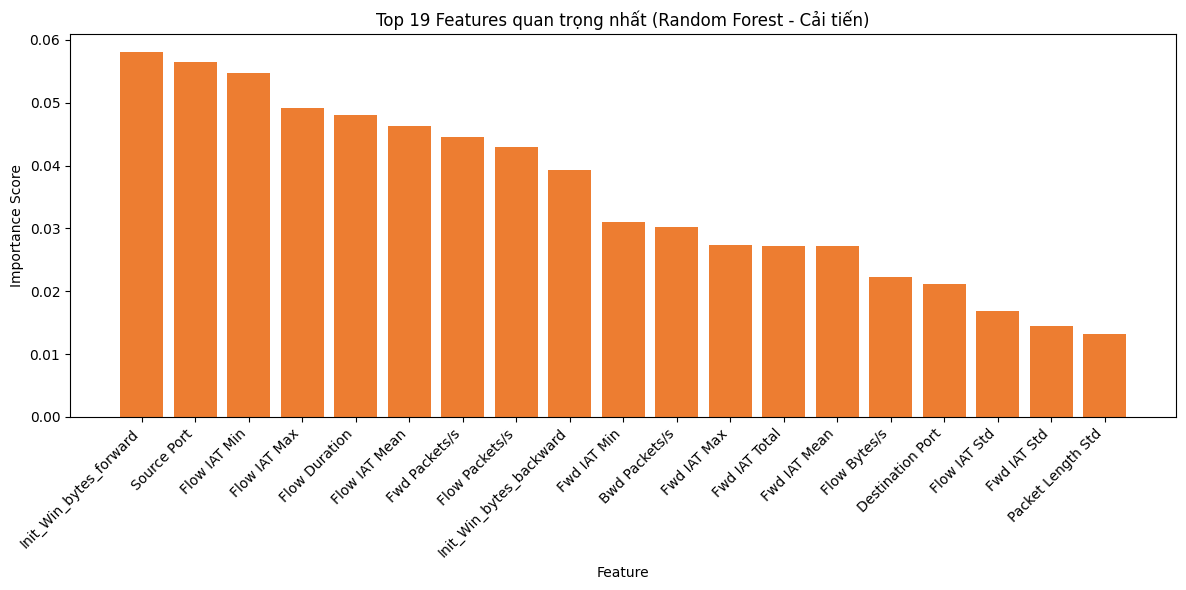

✅ Đã lưu Feature Importance Random Forest!


In [23]:
# Feature Importance của Random Forest
importances_rf = rf.feature_importances_
indices_rf = importances_rf.argsort()[::-1][:19]

plt.figure(figsize=(12, 6))
plt.bar(range(19), importances_rf[indices_rf], color='#ed7d31')
plt.xticks(range(19), [X.columns[i] for i in indices_rf], rotation=45, ha='right')
plt.title('Top 19 Features quan trọng nhất (Random Forest - Cải tiến)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300)
plt.show()
print("✅ Đã lưu Feature Importance Random Forest!")

In [24]:
import os
import zipfile

# Tạo file zip chứa tất cả kết quả
zip_filename = 'B9D54_11_Do_Trung_Kien.zip'

files_to_zip = [
    'phan_phoi_nhan.png',
    'feature_importance.png',
    'feature_importance_rf.png',
    'bieu_do_loss_accuracy.png',
    'bang_ket_qua.png',
    'confusion_matrix.png',
    'confusion_matrix_all.png',
    'confusion_matrix_cai_tien.png',
    'so_sanh_experiment.png',
    'so_sanh_goc_vs_cai_tien.png',
]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for f in files_to_zip:
        path = f'/kaggle/working/{f}'
        if os.path.exists(path):
            zipf.write(path, f)
            print(f"✅ Đã thêm: {f}")
        else:
            print(f"❌ Không tìm thấy: {f}")

print(f"\n📦 Đã tạo file zip: {zip_filename}")
print(f"📁 Kích thước: {os.path.getsize(zip_filename)/1024:.1f} KB")

✅ Đã thêm: phan_phoi_nhan.png
✅ Đã thêm: feature_importance.png
✅ Đã thêm: feature_importance_rf.png
✅ Đã thêm: bieu_do_loss_accuracy.png
✅ Đã thêm: bang_ket_qua.png
✅ Đã thêm: confusion_matrix.png
✅ Đã thêm: confusion_matrix_all.png
✅ Đã thêm: confusion_matrix_cai_tien.png
✅ Đã thêm: so_sanh_experiment.png
✅ Đã thêm: so_sanh_goc_vs_cai_tien.png

📦 Đã tạo file zip: B9D54_11_Do_Trung_Kien.zip
📁 Kích thước: 2090.0 KB
